# PyTorch ile LSTM ve GRU Kullanarak Hisse Senedi Tahmini

Bu notebook, **Amazon (AMZN)** hisse senedinin gecmis 10 yillik kapanis fiyatlarini kullanarak,
bir sonraki gunun fiyatini tahmin eden iki farkli derin ogrenme modelini (**LSTM** ve **GRU**)
karsilastirir. Problem, bir **zaman serisi regresyon** problemidir.

**Is akisi:** Veri cekme -> Normalize -> Kayan pencere (sliding window) -> Model tanimi ->
Egitim -> Degerlendirme (RMSE) -> Karsilastirma.

> **Not:** Hisse senedi fiyat tahmini dogasi geregi zordur; buradaki amac piyasadan kar etmek
> degil, RNN tabanli modellerle uctan uca bir ML is akisi kurmayi ogrenmektir.
> Kritik degerlendirme icin notebook sonundaki *Sonuclar ve Sinirlamalar* bolumune bakiniz.

## 1. Veri Cekme

`yfinance` kutuphanesi ile AMZN'in 2015-2025 arasi gunluk verisi indirilir ve yalnizca
`Close` (kapanis) fiyati kullanilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# 1. Amazon (AMZN) hisse senedi verilerini çekelim
ticker = "AMZN"
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")

# Sadece 'Close' (Kapanış) fiyatına odaklanıyoruz
df = data[['Close']].copy()
print(f"Toplam Veri Sayısı: {len(df)}")
df.head()


/Users/nisankarael/Desktop/microsoft staj/stock-prediction-pytorch/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

Toplam Veri Sayısı: 2516


Price,Close
Ticker,AMZN
Date,
2015-01-02,15.4260
2015-01-05,15.1095
2015-01-06,14.7645
2015-01-07,14.9210
2015-01-08,15.0230


## 2. Veri On Isleme

Fiyatlar `MinMaxScaler` ile `[-1, 1]` araligina normalize edilir. Ardindan **kayan pencere**
yontemiyle her 20 gunluk dizi, 21. gunun fiyatini tahmin edecek sekilde girdi/hedef ciftlerine
donusturulur. Zaman serisi oldugu icin veri **karistirilmadan** ilk %80 egitim, son %20 test
olarak ayrilir ve PyTorch tensorlerine cevrilir.

In [2]:
# 2. Veriyi [-1, 1] aralığına normalize etme
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# 3. Kayan Pencere (Sliding Window) Fonksiyonu
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

LOOKBACK = 20  # Model, geçmiş 20 güne bakarak sonraki günü tahmin edecek
X, y = create_sequences(scaled_data, LOOKBACK)

# 4. Train / Test Split (%80 Eğitim, %20 Test) - Zaman serisinde veri karıştırılmaz!
train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# PyTorch Tensörlerine Dönüştürme
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"X_train boyutu: {X_train.shape}")  # Çıktı: [Eğitim Sayısı, 20, 1] olmalı
print(f"y_train boyutu: {y_train.shape}")


X_train boyutu: torch.Size([1996, 20, 1])
y_train boyutu: torch.Size([1996, 1])


## 3. LSTM Modelinin Tanimlanmasi

`nn.LSTM` uzerine bir dogrusal cikis katmani eklenmis kucuk bir model. Girdi boyutu 1
(tek ozellik), 32 gizli birim, 2 katman ve tek cikis noronu kullanilir. Kayip fonksiyonu
olarak MSE, optimizer olarak Adam secilmistir.

In [3]:
# ==========================================
# 3. LSTM MODEL MIMARISININ TANIMLANMASI
# ==========================================
class StockLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(StockLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Katmani
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # Tam baglantili (Linear) cikis katmani
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Hidden state (h0) ve Cell state (c0) her batch icin sifirdan baslatilir
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # Ileri besleme (Forward pass)
        out, _ = self.lstm(x, (h0, c0))

        # Sadece son zaman adiminin ciktisini dogrusal katmana veriyoruz
        out = self.fc(out[:, -1, :])
        return out

# Ortak hiperparametreler (LSTM ve GRU ayni degerleri kullanir)
INPUT_DIM = 1      # Tek ozellik: kapanis fiyati
HIDDEN_DIM = 32
NUM_LAYERS = 2
OUTPUT_DIM = 1     # Tek deger tahmini

model_lstm = StockLSTM(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=OUTPUT_DIM)
criterion = nn.MSELoss()                                        # Regresyon icin MSE
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)  # Adam optimizer

print("LSTM Modeli ve Kayip Fonksiyonu Basariyla Olusturuldu!")

LSTM Modeli ve Kayip Fonksiyonu Basariyla Olusturuldu!


## 4. LSTM Modelinin Egitilmesi

Model 50 epoch boyunca egitilir. Her epoch'ta ileri besleme, kayip hesaplama, geri yayilim
ve agirlik guncellemesi yapilir. Egitim suresi olculur ve kayip grafigi cizilir.

LSTM Modeli eğitilmeye başlanıyor...
Epoch [5/50], Kayıp (Loss): 0.165660
Epoch [10/50], Kayıp (Loss): 0.043578
Epoch [15/50], Kayıp (Loss): 0.030653
Epoch [20/50], Kayıp (Loss): 0.016787
Epoch [25/50], Kayıp (Loss): 0.010248
Epoch [30/50], Kayıp (Loss): 0.006250
Epoch [35/50], Kayıp (Loss): 0.004308
Epoch [40/50], Kayıp (Loss): 0.004573
Epoch [45/50], Kayıp (Loss): 0.003496
Epoch [50/50], Kayıp (Loss): 0.002275
Eğitim tamamlandı! Toplam süre: 3.16 saniye.


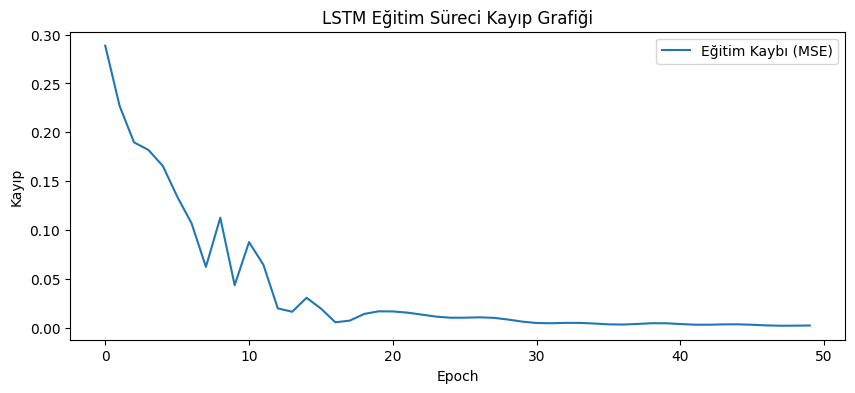

In [4]:
# ==========================================
# 6. LSTM MODELİNİN EĞİTİLMESİ (TRAINING)
# ==========================================
import time

NUM_EPOCHS = 50
train_losses = []

print("LSTM Modeli eğitilmeye başlanıyor...")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_lstm.train()
    
    # İleri besleme (Forward pass)
    outputs = model_lstm(X_train)
    optimizer.zero_grad()
    
    # Hata hesaplama (Loss computation)
    loss = criterion(outputs, y_train)
    
    # Geriye yayılım ve optimizasyon (Backward pass)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Her 5 epochta bir durumu ekrana yazdıralım
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Kayıp (Loss): {loss.item():.6f}")

end_time = time.time()
print(f"Eğitim tamamlandı! Toplam süre: {end_time - start_time:.2f} saniye.")

# Kayıp (Loss) grafiğini çizdirelim
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Eğitim Kaybı (MSE)")
plt.title("LSTM Eğitim Süreci Kayıp Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Kayıp")
plt.legend()
plt.show()

## 5. GRU Modelinin Tanimlanmasi ve Egitilmesi

GRU, LSTM ile ayni hiperparametreleri kullanir. Tek yapisal fark: GRU'da cell state (c0)
bulunmaz, yalnizca hidden state (h0) vardir. Boylece iki mimari adil bicimde karsilastirilabilir.

In [5]:
# ==========================================
# 7. GRU MODEL MİMARİSİ VE EĞİTİMİ
# ==========================================
class StockGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(StockGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # GRU Katmanı
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Çıkış katmanı
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # GRU'da sadece hidden state (h0) vardır, cell state (c0) bulunmaz
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

# GRU Modelini örnekleme (Aynı hiperparametreler ile)
model_gru = StockGRU(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=OUTPUT_DIM)
criterion_gru = nn.MSELoss()
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.01)

# GRU Eğitimi
gru_losses = []
print("GRU Modeli eğitilmeye başlanıyor...")
gru_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_gru.train()
    outputs = model_gru(X_train)
    optimizer_gru.zero_grad()
    
    loss = criterion_gru(outputs, y_train)
    loss.backward()
    optimizer_gru.step()
    
    gru_losses.append(loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Kayıp (Loss): {loss.item():.6f}")

gru_end_time = time.time()
lstm_duration = end_time - start_time
gru_duration = gru_end_time - gru_start_time

print(f"\n[SÜRE KARŞILAŞTIRMASI]")
print(f"LSTM Eğitim Süresi: {lstm_duration:.2f} saniye")
print(f"GRU Eğitim Süresi: {gru_duration:.2f} saniye")

GRU Modeli eğitilmeye başlanıyor...
Epoch [5/50], Kayıp (Loss): 0.089595
Epoch [10/50], Kayıp (Loss): 0.038502
Epoch [15/50], Kayıp (Loss): 0.013331
Epoch [20/50], Kayıp (Loss): 0.000878
Epoch [25/50], Kayıp (Loss): 0.003474
Epoch [30/50], Kayıp (Loss): 0.003173
Epoch [35/50], Kayıp (Loss): 0.000749
Epoch [40/50], Kayıp (Loss): 0.001525
Epoch [45/50], Kayıp (Loss): 0.001030
Epoch [50/50], Kayıp (Loss): 0.000672

[SÜRE KARŞILAŞTIRMASI]
LSTM Eğitim Süresi: 3.16 saniye
GRU Eğitim Süresi: 3.23 saniye


## 6. Test Verisiyle Degerlendirme ve Karsilastirma

Her iki model test setinde tahmin uretir. Normalize degerler `inverse_transform` ile gercek
USD olcegine dondurulur ve **RMSE** hesaplanir. Son olarak gercek ve tahmin edilen fiyatlar
tek grafikte gorsellestirilir.

[PERFORMANS METRİKLERİ]
LSTM Test RMSE: 11.24 USD
GRU Test RMSE: 4.97 USD



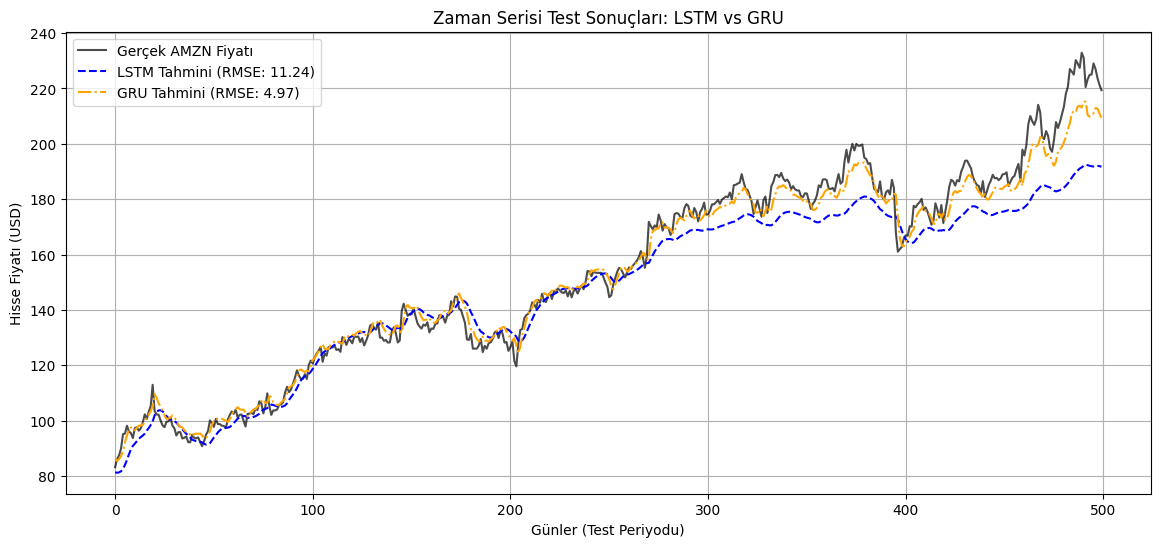

In [6]:
# ==========================================
# 8. TEST VERİSİ İLE TAHMİN VE KARŞILAŞTIRMA
# ==========================================
from sklearn.metrics import mean_squared_error

# Modelleri değerlendirme moduna alalım
model_lstm.eval()
model_gru.eval()

with torch.no_grad():
    # Test verisi üzerinde tahmin üretme
    lstm_preds = model_lstm(X_test).numpy()
    gru_preds = model_gru(X_test).numpy()

# Normalize edilmiş değerleri gerçek fiyat ölçeğine geri döndürelim (Inverse Transform)
lstm_preds_actual = scaler.inverse_transform(lstm_preds)
gru_preds_actual = scaler.inverse_transform(gru_preds)
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Metriklerin Hesaplanması (RMSE)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds_actual))
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_preds_actual))

print(f"[PERFORMANS METRİKLERİ]")
print(f"LSTM Test RMSE: {lstm_rmse:.2f} USD")
print(f"GRU Test RMSE: {gru_rmse:.2f} USD\n")

# Gerçek ve Tahmin Edilen Fiyatların Görselleştirilmesi
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label="Gerçek AMZN Fiyatı", color="black", alpha=0.7)
plt.plot(lstm_preds_actual, label=f"LSTM Tahmini (RMSE: {lstm_rmse:.2f})", color="blue", linestyle="--")
plt.plot(gru_preds_actual, label=f"GRU Tahmini (RMSE: {gru_rmse:.2f})", color="orange", linestyle="-.")
plt.title("Zaman Serisi Test Sonuçları: LSTM vs GRU")
plt.xlabel("Günler (Test Periyodu)")
plt.ylabel("Hisse Fiyatı (USD)")
plt.legend()
plt.grid(True)
plt.show()

## 7. Sonuclar ve Sinirlamalar

| Model | Test RMSE | Egitim Suresi |
|---|---|---|
| **GRU**  | **4.97 USD** | 3.23 sn |
| **LSTM** | 11.24 USD | 3.16 sn |

**Model karsilastirmasi.** Bu deneyde GRU, LSTM'e kiyasla belirgin sekilde daha dusuk test
hatasi verdi. GRU'nun daha az parametreye sahip olmasi, bu boyutta ve tek ozellikli bir veri
setinde daha hizli ve kararli bir ogrenmeye yardimci olmus gorunuyor. Egitim sureleri bu kucuk
veri setinde neredeyse esit cikti.

**Kritik degerlendirme.** Dusuk RMSE, modelin "piyasayi yendigi" anlamina gelmez. Model yalnizca
bir onceki 20 gunun fiyatina bakarak bir sonraki gunu tahmin etmektedir; bu tur modeller cogu
zaman *bir onceki gunun fiyatini tekrar etme* egilimindedir (naive baseline'a yakinsama). Gercek
dunyada hisse fiyatlari buyuk olcude rastgele yuruyuse (random walk) benzer ve tek degiskenli
gecmis fiyat, gelecegi guvenilir bicimde ongormek icin yeterli degildir. Narayanan & Kapoor'un
*AI Snake Oil* calismasinda vurgulandigi gibi, tahmine dayali modellerin basarisi kolayca abartilabilir;
bu yuzden metrikler dikkatli ve supheci bir gozle yorumlanmalidir.

**Olasi sonraki adimlar:**
- Naive baseline (dunun fiyati = bugunun tahmini) ile karsilastirma ekleyerek modelin gercek
  katkisini olcmek
- Ek ozellikler (hacim, hareketli ortalamalar, teknik gostergeler) eklemek
- Dropout / erken durdurma ile overfitting kontrolu
- Transformer tabanli zaman serisi modellerini denemek